In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, avg, round, lit, count, stddev

# 1. Initializing Spark Session with MongoDB Connector
spark = SparkSession.builder \
    .appName("PISA-Reading-Analysis") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.4.0") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

your 131072x1 screen size is bogus. expect trouble
26/04/06 19:15:57 WARN Utils: Your hostname, PC-196937 resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/06 19:15:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/niina37/big-data-project/venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/niina37/.ivy2/cache
The jars for the packages stored in: /home/niina37/.ivy2/jars
org.mongodb.spark#mongo-spark-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-7e8e76fa-d3a1-44ab-b5b3-0dccfa0fe16a;1.0
	confs: [default]
	found org.mongodb.spark#mongo-spark-connector_2.12;10.4.0 in central
	found org.mongodb#mongodb-driver-sync;5.1.4 in central
	[5.1.4] org.mongodb#mongodb-driver-sync;[5.1.1,5.1.99)
	found org.mongodb#bson;5.1.4 in central
	found org.mongodb#mongodb-driver-core;5.1.4 in central
	found org.mongodb#bson-record-codec;5.1.4 in central
:: resolution report :: resolve 1053ms :: artifacts dl 8ms
	:: modules in use:
	org.mongodb#bson;5.1.4 from central in [default]
	org.mongodb#bson-record-codec;5.1.4 from central in [default]
	org.mongodb#mongodb-driver-core;5.1.4 from central in [default]
	org.mongodb#mongodb-driver-sync;5.1.4 from central in [default]
	org.mongodb.spark#mongo-spark-connecto

In [2]:
def get_finland_stats(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load()
    
    fin_df = df.filter(col("CNT") == "FIN")
    
    # Choosing the correct ICT column based on the year
    ict_col_name = "ICTAVHOM_SUM" if "ICTAVHOM_SUM" in df.columns else "ICTAVHOM"
    
    # Averages and rounding directly in Spark
    stats = fin_df.select(
        round(avg("PV1READ"), 2).alias("avg_reading"),
        round(avg(ict_col_name), 2).alias("avg_ict")
    ).collect()[0]
    
    return stats

try:
    print("\n--- PISA ANALYSIS READING: FINLAND 2012 vs 2022 ---\n")
    
    stats_2012 = get_finland_stats(2012)
    stats_2022 = get_finland_stats(2022)
    
    print(f"Year 2012 (Reading): {stats_2012['avg_reading']} points")
    print(f"Year 2012 (ICT Availability): {stats_2012['avg_ict']} (WLE index)")
    print("-" * 40)
    print(f"Year 2022 (Reading): {stats_2022['avg_reading']} points")
    print(f"Year 2022 (ICT Availability): {stats_2022['avg_ict']} (sum variable)")
    
    # Calculating change
    change = stats_2022['avg_reading'] - stats_2012['avg_reading']
    print(f"\nChange in reading proficiency: {change:.2f} points.")

except Exception as e:
    print(f"Error in analysis: {e}")


--- PISA ANALYSIS READING: FINLAND 2012 vs 2022 ---



Year 2012 (Reading): 510.91 points
Year 2012 (ICT Availability): 38.49 (WLE index)
----------------------------------------
Year 2022 (Reading): 477.98 points
Year 2022 (ICT Availability): 5.67 (sum variable)

Change in reading proficiency: -32.93 points.


In [3]:
def get_correlation(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load()
    
    # 1. choosing correct ICT column based on the year
    if "ICTAVHOM_SUM" in df.columns:
        ict_col = "ICTAVHOM_SUM"
    elif "ICTAVHOM" in df.columns:
        ict_col = "ICTAVHOM"
    else:
        print(f"Warning: No ICTAVHOM column found for year {year}.")
        return None

    # 2. Filtering data for Finland and ensuring non-null values for correlation
    fin_df = df.filter(
        (col("CNT") == "FIN") & 
        (col(ict_col).isNotNull()) & 
        (col("PV1MATH").isNotNull())
    )
    
    # 3. Calculating correlation and handling potential exceptions
    try:
        correlation = fin_df.stat.corr(ict_col, "PV1READ")
        return correlation
    except Exception as e:
        print(f"Error calculating correlation for year {year}: {e}")
        return None

corr_2012 = get_correlation(2012)
corr_2022 = get_correlation(2022)

print(f"\n--- CORRELATION ANALYSIS (ICT vs. READING) ---")
print(f"Correlation in 2012: {corr_2012:.3f}")
print(f"Correlation in 2022: {corr_2022:.3f}")


--- CORRELATION ANALYSIS (ICT vs. READING) ---
Correlation in 2012: 0.063
Correlation in 2022: 0.122


In [4]:
def analyze_reading_by_time(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load()
    
    if year == 2012:
        df = df.withColumn("Usage_Group", 
            when(col("ICTWKDY").isin(1, 2, 3), "1. Low (0-1h)")
            .when(col("ICTWKDY").isin(4, 5), "2. Moderate (1-4h)")
            .when(col("ICTWKDY").isin(6, 7), "3. Heavy (4h+)")
            .otherwise(None))
    else:
        df = df.withColumn("Usage_Group", 
            when(col("ICTWKDY") < -0.5, "1. Low (Below Avg)")
            .when((col("ICTWKDY") >= -0.5) & (col("ICTWKDY") <= 1.0), "2. Moderate (Avg)")
            .when(col("ICTWKDY") > 1.0, "3. Heavy (High Use)")
            .otherwise(None))

    stats = df.filter((col("CNT") == "FIN") & (col("Usage_Group").isNotNull())) \
        .groupBy("Usage_Group") \
        .agg(
            round(avg("PV1READ"), 1).alias("Avg_Reading"),
            count("PV1READ").alias("N_Students") 
        ).orderBy("Usage_Group")
    
    return stats

try:
    print("\n--- READING VS. ICT USAGE IN FINLAND ---")
    print("Year 2012:")
    analyze_reading_by_time(2012).show()
    
    print("\nYear 2022:")
    analyze_reading_by_time(2022).show()

except Exception as e:
    print(f"Error in analysis: {e}")


--- READING VS. ICT USAGE IN FINLAND ---
Year 2012:
+------------------+-----------+----------+
|       Usage_Group|Avg_Reading|N_Students|
+------------------+-----------+----------+
|     1. Low (0-1h)|      524.1|      1910|
|2. Moderate (1-4h)|      517.5|      5309|
|    3. Heavy (4h+)|      498.4|      1257|
+------------------+-----------+----------+


Year 2022:
+-------------------+-----------+----------+
|        Usage_Group|Avg_Reading|N_Students|
+-------------------+-----------+----------+
| 1. Low (Below Avg)|      505.4|      1728|
|  2. Moderate (Avg)|      500.9|      5451|
|3. Heavy (High Use)|      430.7|      1056|
+-------------------+-----------+----------+



In [5]:
def check_reading_correlation(year):
    uri = f"mongodb://127.0.0.1:27017/pisa_database.year{year}"
    df = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", uri).load()
    
    # Filter for Finland and ensure non-null values for correlation
    fin_df = df.filter(
        (col("CNT") == "FIN") & 
        (col("ICTWKDY").isNotNull()) & 
        (col("PV1READ").isNotNull())
    )
    
    # Calculate correlation
    r = fin_df.stat.corr("ICTWKDY", "PV1READ")
    
    # Calculate standard deviation, which indicates variation within the group
    std_dev = fin_df.select(stddev("PV1READ")).collect()[0][0]
    
    return r, std_dev

try:
    r12, sd12 = check_reading_correlation(2012)
    r22, sd22 = check_reading_correlation(2022)
    
    print("\n--- READING VS. ICT USAGE IN FINLAND ---")
    print(f"Year 2012: r = {r12:.3f} (Standard Deviation: {sd12:.1f})")
    print(f"Year 2022: r = {r22:.3f} (Standard Deviation: {sd22:.1f})")
    
    # Calculate change in correlation as a percentage of the initial value
    print(f"\nAnalysis: Correlation has changed by {((r22-r12)/abs(r12))*100:.1f} %")

except Exception as e:
    print(f"Error: {e}")


--- READING VS. ICT USAGE IN FINLAND ---
Year 2012: r = -0.260 (Standard Deviation: 100.4)
Year 2022: r = -0.195 (Standard Deviation: 103.7)

Analysis: Correlation has changed by 25.1 %


In [6]:
%pip install setuptools

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd

# 1. Getting and preparing 2012 data (Reading)
df_12_raw = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", "mongodb://127.0.0.1:27017/pisa_database.year2012").load()
df_12_sub = df_12_raw.filter(col("CNT") == "FIN").select(col("PV1READ").alias("Score"), col("ICTWKDY"), lit("2012").alias("Year"))
df_12_sub = df_12_sub.withColumn("Usage_Group", 
    when(col("ICTWKDY").isin(1, 2, 3), "1. Low (0-1h)")
    .when(col("ICTWKDY").isin(4, 5), "2. Moderate (1-4h)")
    .when(col("ICTWKDY").isin(6, 7), "3. Heavy (4h+)")
    .otherwise(None)).filter(col("Usage_Group").isNotNull())

# 2. Getting and preparing 2022 data (Reading)
df_22_raw = spark.read.format("mongodb").option("spark.mongodb.read.connection.uri", "mongodb://127.0.0.1:27017/pisa_database.year2022").load()
df_22_sub = df_22_raw.filter(col("CNT") == "FIN").select(col("PV1READ").alias("Score"), col("ICTWKDY"), lit("2022").alias("Year"))
df_22_sub = df_22_sub.withColumn("Usage_Group", 
    when(col("ICTWKDY") < -0.5, "1. Low (0-1h)")
    .when((col("ICTWKDY") >= -0.5) & (col("ICTWKDY") <= 1.0), "2. Moderate (1-4h)")
    .when(col("ICTWKDY") > 1.0, "3. Heavy (4h+)")
    .otherwise(None)).filter(col("Usage_Group").isNotNull())

# 3. Combining data and converting to Pandas for visualization (use .limit(5000) if memory issues arise
df_combined = df_12_sub.union(df_22_sub).toPandas()

df_combined["Score"] = pd.to_numeric(df_combined["Score"])
print("Data valmiina visualisointiin!")

Data valmiina visualisointiin!


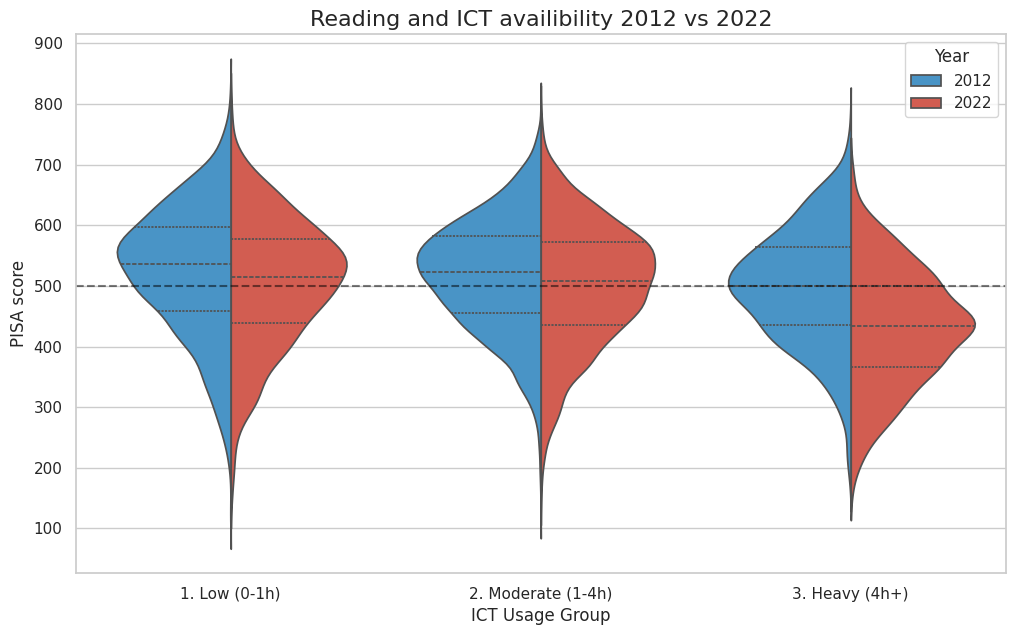

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Transform Usage_Group to ordered categorical for better plotting
df_combined["Usage_Group"] = pd.Categorical(df_combined["Usage_Group"], 
    categories=["1. Low (0-1h)", "2. Moderate (1-4h)", "3. Heavy (4h+)"], 
    ordered=True)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.violinplot(x="Usage_Group", y="Score", hue="Year", data=df_combined, 
                    split=True, inner="quart", palette={"2012": "#3498db", "2022": "#e74c3c"})

plt.title('Reading and ICT availibility 2012 vs 2022', fontsize=16)
plt.ylabel('PISA score')
plt.xlabel('ICT Usage Group')

plt.axhline(500, color='black', linestyle='--', alpha=0.5)

plt.show()

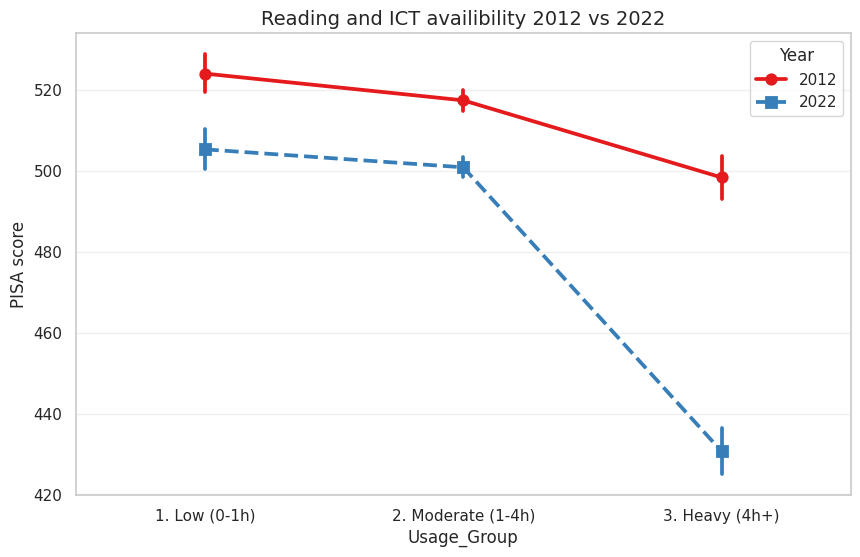

In [14]:
plt.figure(figsize=(10, 6))


sns.pointplot(x="Usage_Group", y="Score", hue="Year", data=df_combined, 
              markers=["o", "s"], linestyles=["-", "--"], palette="Set1")

plt.title('Reading and ICT availibility 2012 vs 2022', fontsize=14)
plt.ylabel('PISA score')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

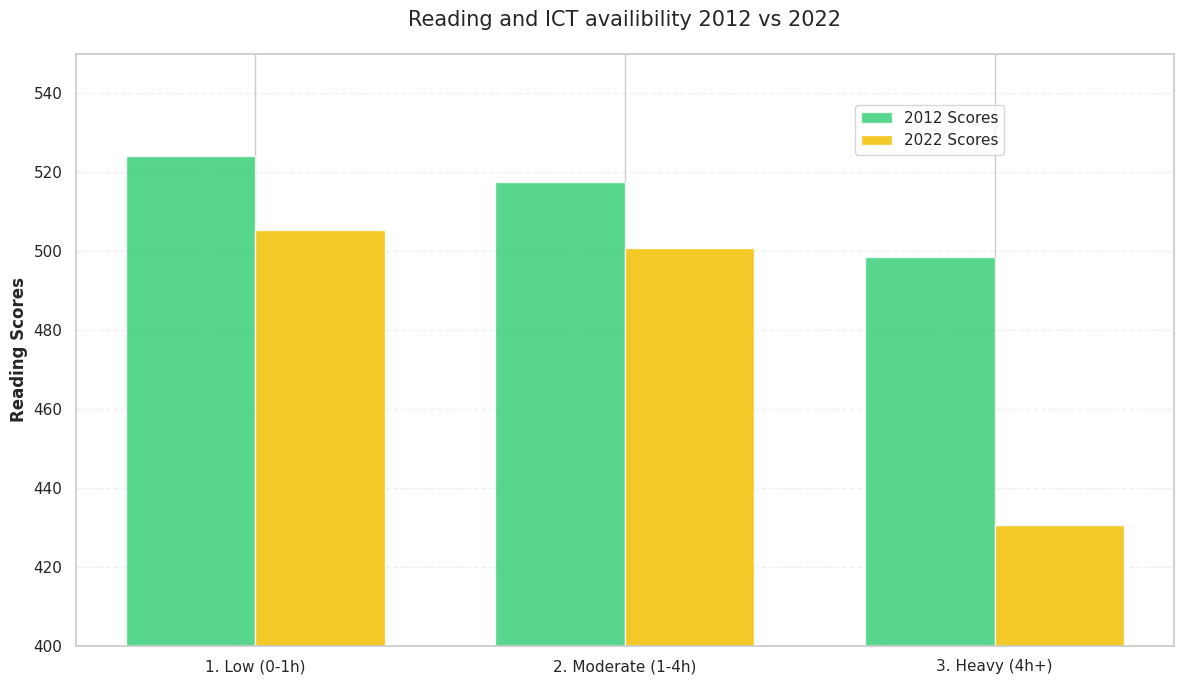

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# --- DATA READING ---
labels = ['1. Low (0-1h)', '2. Moderate (1-4h)', '3. Heavy (4h+)']
read_2012 = [524.1, 517.5, 498.4]
read_2022 = [505.4, 500.9, 430.7]

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 7))

# Axis 1: Bars (Scores)
rects1 = ax1.bar(x - width/2, read_2012, width, label='2012 Scores', color='#2ecc71', alpha=0.8)
rects2 = ax1.bar(x + width/2, read_2022, width, label='2022 Scores', color='#f1c40f', alpha=0.9)

ax1.set_ylabel('Reading Scores', fontsize=12, fontweight='bold')
ax1.set_ylim(400, 550)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.title('Reading and ICT availibility 2012 vs 2022', fontsize=15, pad=20)
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))

plt.tight_layout()
plt.show()